## High Volatility feature

In [9]:
import pandas as pd
import numpy as np

print("1. Loading V2.5 15-Minute Dataset...")

df = pd.read_csv('V2.5_15min_features.csv')

#convert datetime to UTC then to Helsinki timezone
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Europe/Helsinki')
df = df.sort_values('datetime').reset_index(drop=True)

print("2. Defining 'High Volatility' Threshold...")
# use rolling std to define high volatility
df['price_roll_std_6h'] = df['price'].rolling(window=24).std()

# delete rows with NaN values in 'price_roll_std_6h' column
df = df.dropna(subset=['price_roll_std_6h']).copy()

vol_threshold = df['price_roll_std_6h'].quantile(0.85)
print(f"   -> Top 15% Volatility Threshold: {vol_threshold:.2f}")

print("3. Creating the Binary Classification Target (0 or 1)...")
df['is_high_volatility'] = (df['price_roll_std_6h'] >= vol_threshold).astype(int)
print(df['is_high_volatility'].value_counts(normalize=True) * 100)

1. Loading V2.5 15-Minute Dataset...
2. Defining 'High Volatility' Threshold...
   -> Top 15% Volatility Threshold: 24.08
3. Creating the Binary Classification Target (0 or 1)...
is_high_volatility
0    84.999952
1    15.000048
Name: proportion, dtype: float64


In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("4. Selecting Safe Features for the Classifier...")

# temp_lag_4 = one of the lag features, which is safe to use for classification
vol_features = ['temp', 'wind_speed', 'wind_direction_deg', 'temp_lag_4',
                'hour', 'day_of_week', 'month']

X_vol = df[vol_features]
y_vol = df['is_high_volatility']

# to make sure there are no NaN values in the features, we can drop rows with NaN values
mask = X_vol.notna().all(axis=1)
X_vol, y_vol = X_vol[mask], y_vol[mask]

X_vol_train, X_vol_test, y_vol_train, y_vol_test = train_test_split(
    X_vol, y_vol, test_size=0.2, shuffle=False
)

print("5. Initializing and Training the XGBoost Risk Classifier...")
risk_model = XGBClassifier(
    n_estimators=100,       
    learning_rate=0.05,
    max_depth=5,            # depth of each tree,as a hyperparameter, can be tuned
    objective='binary:logistic',  # binary classification
    random_state=42         # lock the random seed for reproducibility
)
risk_model.fit(X_vol_train, y_vol_train)

print("6. Evaluating the Risk Classifier (NEW STEP)...")
y_pred = risk_model.predict(X_vol_test)
print('Test accuracy:', round(accuracy_score(y_vol_test, y_pred), 4))
print(classification_report(y_vol_test, y_pred))

print("7. Extracting the High-Volatility Probabilities...")
# predict_proba returns [safe probability, high-volatility probability], take the second column [:, 1]

proba = pd.Series(risk_model.predict_proba(X_vol)[:, 1], index=X_vol.index)
df['high_volatility_prob'] = proba

print("   -> New feature 'high_volatility_prob' created!")
df[['datetime', 'price', 'is_high_volatility', 'high_volatility_prob']].tail(10)

4. Selecting Safe Features for the Classifier...
5. Initializing and Training the XGBoost Risk Classifier...
6. Evaluating the Risk Classifier (NEW STEP)...
Test accuracy: 0.8431
              precision    recall  f1-score   support

           0       0.86      0.97      0.91     17398
           1       0.60      0.24      0.35      3599

    accuracy                           0.84     20997
   macro avg       0.73      0.61      0.63     20997
weighted avg       0.82      0.84      0.81     20997

7. Extracting the High-Volatility Probabilities...
   -> New feature 'high_volatility_prob' created!


,datetime,price,is_high_volatility,high_volatility_prob
105206,2025-12-31 21:30:00+02:00,125.63,0,0.359166
105207,2025-12-31 21:45:00+02:00,109.99,0,0.378926
105208,2025-12-31 22:00:00+02:00,146.28,0,0.368777
105209,2025-12-31 22:15:00+02:00,149.97,0,0.320035
105210,2025-12-31 22:30:00+02:00,120.29,0,0.371604
105211,2025-12-31 22:45:00+02:00,103.11,0,0.430291
105212,2025-12-31 23:00:00+02:00,146.90,0,0.364726
105213,2025-12-31 23:15:00+02:00,110.00,0,0.413759
105214,2025-12-31 23:30:00+02:00,106.82,0,0.402957
105215,2025-12-31 23:45:00+02:00,99.22,0,0.368027


In [ ]:
print("8. Saving the new V2.5.1 Matrix (V2.5.1+ Risk Feature)...")
#save
save_path = 'V2.5.1_15min_Risk_Enhanced_Dataset.csv'
df.to_csv(save_path, index=False)
print(f"Matrix saved to: {save_path}")

8. Saving the new V2.5.1 Matrix (V2.5.1+ Risk Feature)...
Matrix saved to: V2.5.1_15min_Risk_Enhanced_Dataset.csv


### Histogram Validation: Is the “high volatility” feature actually useful? If the probability of “high volatility periods” is significantly higher than that of “stable periods” (and the two histograms are clearly distinguishable), this indicates that the feature is informative; if they overlap completely, it indicates that the feature is useless.

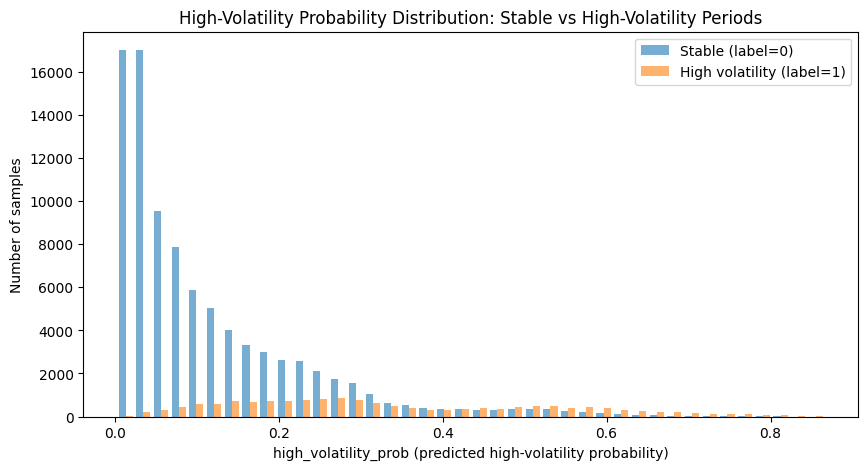

Stable periods       mean prob: 0.113   median: 0.070
High-volatility      mean prob: 0.341   median: 0.295
-> The larger the gap between the two distributions, the more useful the feature.


In [12]:
import matplotlib.pyplot as plt

high = df.loc[df['is_high_volatility'] == 1, 'high_volatility_prob'].dropna()
low  = df.loc[df['is_high_volatility'] == 0, 'high_volatility_prob'].dropna()

plt.figure(figsize=(10, 5))
plt.hist([low, high], bins=40, alpha=0.6,
         label=['Stable (label=0)', 'High volatility (label=1)'])
plt.xlabel('high_volatility_prob (predicted high-volatility probability)')
plt.ylabel('Number of samples')
plt.title('High-Volatility Probability Distribution: Stable vs High-Volatility Periods')
plt.legend()
plt.show()

print(f'Stable periods       mean prob: {low.mean():.3f}   median: {low.median():.3f}')
print(f'High-volatility      mean prob: {high.mean():.3f}   median: {high.median():.3f}')
print('-> The larger the gap between the two distributions, the more useful the feature.')